# EDA: Before vs. After — Encoding Categorical Variables (Member 2)
Compares the dataset **before** encoding (Member 3's output — still has text categories)
against **after** (everything converted to numbers).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_before = pd.read_csv("output_after_outlier_removal.csv")
df_after = pd.read_csv("output_after_encoding.csv")

print("Before shape:", df_before.shape)
print("After shape:", df_after.shape)
print()
print("Before dtypes:")
print(df_before.dtypes)

Before shape: (100000, 6)
After shape: (100000, 30)

Before dtypes:
attraction_level           str
attraction_category        str
province                   str
ticket_price             int64
spend_amount           float64
satisfaction_level         str
dtype: object


## EDA 1 — Column Count: Before vs. After (the one-hot expansion)

In [2]:
col_counts = pd.Series({"Before (6 columns)": df_before.shape[1],
                          "After (30 columns)": df_after.shape[1]})
col_counts

Before (6 columns)     6
After (30 columns)    30
dtype: int64

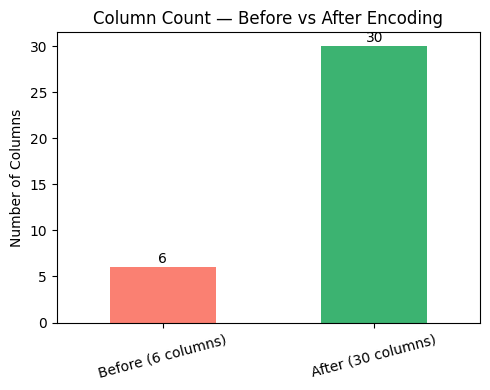

In [3]:
plt.figure(figsize=(5, 4))
col_counts.plot(kind="bar", color=["salmon", "mediumseagreen"])
plt.ylabel("Number of Columns")
plt.title("Column Count — Before vs After Encoding")
plt.xticks(rotation=15)
for i, v in enumerate(col_counts):
    plt.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.show()

**Interpretation:** Went from 6 columns to 30 — almost entirely because one-hot encoding
`attraction_category` (26 different categories) created 25 separate binary columns. This is the
direct cost of one-hot encoding: it trades a wider dataset for avoiding a false sense of order
between categories.

## EDA 2 — Data Types: Before vs. After (proves everything is numeric now)

In [4]:
dtype_summary = pd.DataFrame({
    "Before": df_before.dtypes.astype(str).value_counts(),
    "After": df_after.dtypes.astype(str).value_counts()
}).fillna(0).astype(int)
dtype_summary

,Before,After
bool,0,25
float64,1,2
int64,1,2
str,4,1


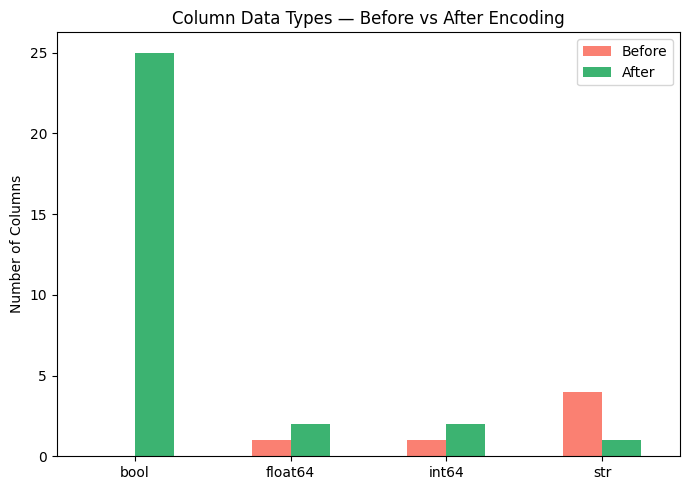

In [5]:
dtype_summary.plot(kind="bar", figsize=(7, 5), color=["salmon", "mediumseagreen"])
plt.ylabel("Number of Columns")
plt.title("Column Data Types — Before vs After Encoding")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Before encoding, several columns were `object` (text) type — models
can't use these directly. After encoding, every single column is numeric (`int64`/`float64`/`bool`
for the one-hot flags) — exactly what's needed to feed into a model.

## EDA 3 — `attraction_level` (3 text categories) vs. `attraction_level_encoded` (0/1/2)

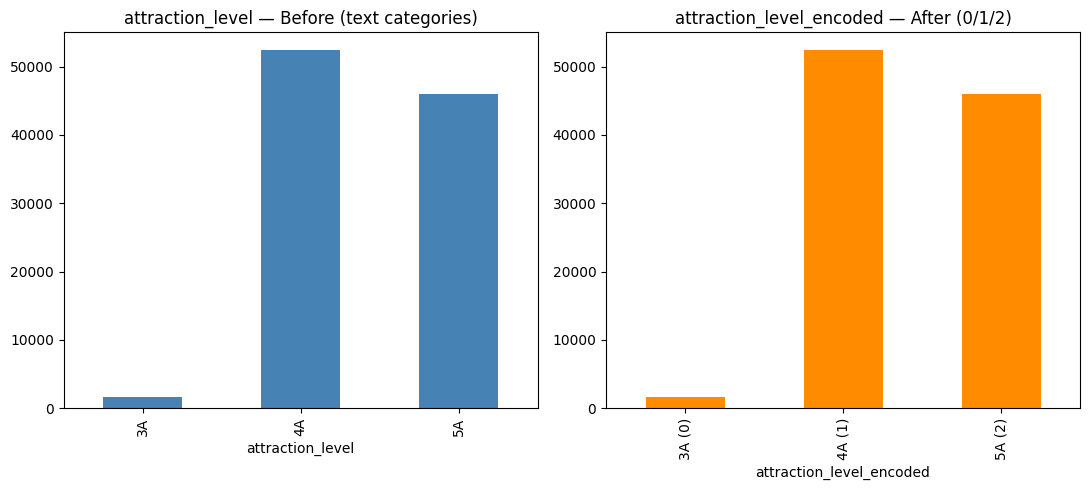

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
df_before["attraction_level"].value_counts().reindex(["3A", "4A", "5A"]).plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("attraction_level — Before (text categories)")
df_after["attraction_level_encoded"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="darkorange")
axes[1].set_xticklabels(["3A (0)", "4A (1)", "5A (2)"])
axes[1].set_title("attraction_level_encoded — After (0/1/2)")
plt.tight_layout()
plt.show()

**Interpretation:** The bar heights (counts per category) are identical before and after —
Label Encoding didn't change *how many* tourists are in each group, it just renamed the labels
from text ("3A"/"4A"/"5A") to numbers (0/1/2) that preserve the same real order.

## EDA 4 — `province_target_enc`: Distribution of the New Encoded Column

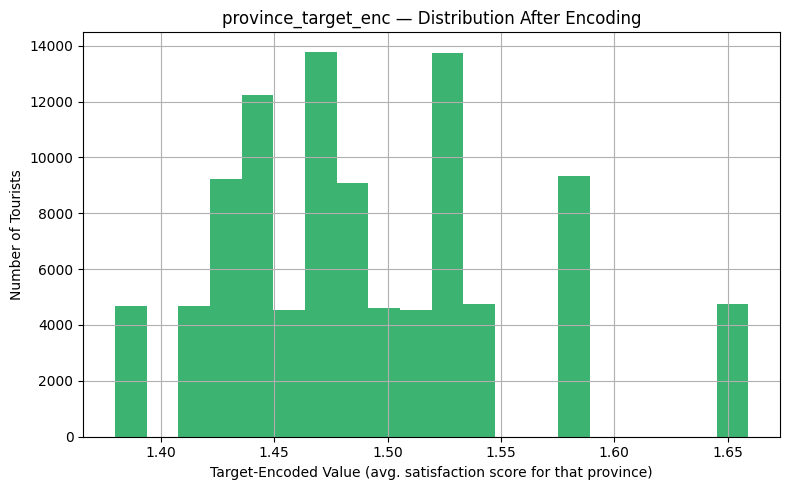

In [7]:
plt.figure(figsize=(8, 5))
df_after["province_target_enc"].hist(bins=20, color="mediumseagreen")
plt.xlabel("Target-Encoded Value (avg. satisfaction score for that province)")
plt.ylabel("Number of Tourists")
plt.title("province_target_enc — Distribution After Encoding")
plt.tight_layout()
plt.show()

**Interpretation:** This column didn't exist before — `province` (22 text categories) was
compressed into this single number per row, where each value represents the average satisfaction
score of tourists who visited that same province. Most provinces cluster together in the middle
of this range, with a few standing out at the edges as notably higher- or lower-satisfaction
destinations.